# 05 Transfer Learning with CNNs

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load a **pre-trained** CNN (e.g. MobileNetV2) and reuse its feature layers
- **Freeze** the base and train only a new head on a small dataset (e.g. MNIST or a subset)
- See why we use transfer learning instead of training from scratch when data is limited

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 02 "Bias-Variance Tradeoff and Learning Curves" — a small dataset overfits a large model; transfer learning is the standard answer to that curve.

---

## 🌍 Real life

**📌 Real case — the study that tested the default and found it wanting.** By 2019, "start from ImageNet weights" had become automatic in medical imaging. Raghu, Zhang, Kleinberg and Bengio put it to the test in **"Transfusion: Understanding Transfer Learning for Medical Imaging"** (NeurIPS 2019) across two large-scale medical imaging tasks, and reported that "transfer offers little benefit to performance, and simple, lightweight models can perform comparably to ImageNet architectures" — the gains they did find traced to **over-parametrization** rather than to sophisticated feature reuse. Transfer learning is a powerful default. It is a default, not a law, and this notebook's own numbers will show you why.

**⚡ Why this matters — what goes wrong without it.** Training a CNN from scratch means spending your labelled data on learning edges and textures *before* it gets to learn your actual task, and most projects do not have enough data for both. Freezing gives you **2,236,682** parameters of ready-made visual vocabulary for the price of a download, and leaves you **12,810** to train — **0.57%** of the model. When the domains match, that is the cheapest win in deep learning.

**Where is this used?** Transfer learning is used in **medical imaging**, **custom classifiers** (e.g. product recognition), and **mobile vision** when we have limited labeled data.

**In this notebook we use** a **pre-trained model** (e.g. MobileNetV2) and **freeze** its base, then **train only the new head** on our data. We use **transfer learning** (instead of training from scratch) **because** the pre-trained layers already learned useful features (edges, textures); we reuse them and need **less data and time**.

**📌 Covers slide(s):** **20** — Transfer Learning (VGG, ResNet, fine-tuning). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below. First run may download the pre-trained weights.


In [1]:
# Transfer Learning with PyTorch — torchvision models
# torchvision.models provides pretrained CNNs; transforms handles the preprocessing they expect.
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
print(f"PyTorch {torch.__version__}")
print("torchvision loaded for pretrained models")

PyTorch 2.13.0
torchvision loaded for pretrained models


## Theory (short)

- **Transfer learning:** Take a model trained on a large dataset (e.g. ImageNet); **freeze** most layers and **replace the head** (classification layer) for our classes.
- **Freeze vs fine-tune:** Freeze = don't update base weights; only train the new head. Fine-tune = later unfreeze some layers and train with a small learning rate.
- **When to use:** Use when we have **limited data** or **similar domain** (e.g. natural images). Pre-trained features generalize well.
- **We use a pre-trained base** instead of training from scratch so we reuse learned features and train faster with less data.

In [2]:
# Step 1: Load MobileNetV2 (pretrained on ImageNet) as base feature extractor
base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)  # real ImageNet weights (cached locally)
# Freeze all parameters (feature extractor stays fixed)
for param in base.parameters():
    param.requires_grad = False

frozen = sum(1 for p in base.parameters() if not p.requires_grad)
print(f"Frozen parameters: {frozen:,}")
print(f"Architecture: {type(base).__name__}")
print("All feature layers frozen — only new head will train")

Frozen parameters: 158
Architecture: MobileNetV2
All feature layers frozen — only new head will train


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras (MobileNetV2 or similar), NumPy. We use MNIST resized to the model input size (e.g. 96×96 or 224×224) so we don't need a new dataset.

**Dataset:** Real — MNIST (resized for transfer learning).

**Outputs:** Model summary, training loss/accuracy for the new head (2 epochs), and test accuracy.

In [3]:
# Step 2: Replace classifier head for MNIST (10 classes)
# MobileNetV2 outputs 1280 features → we add a 10-class head
num_features = base.classifier[1].in_features   # 1280
base.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 10)   # 10 classes for MNIST
)
# Now only the new head is trainable
trainable = sum(p.numel() for p in base.parameters() if p.requires_grad)
total     = sum(p.numel() for p in base.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
print("Transfer learning: frozen base + fresh trainable head")

Trainable params: 12,810 / 2,236,682 (0.57%)
Transfer learning: frozen base + fresh trainable head


## Step 3: Prepare MNIST as 96×96 RGB (to match MobileNetV2 input)

In [4]:
# Step 3: Prepare MNIST as 96x96 RGB (MobileNetV2 needs 3-channel input)
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

transform = T.Compose([
    T.Resize(96),
    T.Grayscale(num_output_channels=3),   # 1-channel digits -> 3-channel RGB
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])
train_full = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transform)

# classroom-sized subsets so the demo runs in minutes on CPU
train_ds = Subset(train_full, range(2000))
test_ds  = Subset(test_full,  range(500))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

x0, y0 = next(iter(train_dl))
print(f"Train subset: {len(train_ds)} images | Test subset: {len(test_ds)} images")
print(f"Batch shape: {x0.shape}  (batch x 3 channels x 96 x 96)")

Train subset: 2000 images | Test subset: 500 images
Batch shape: torch.Size([64, 3, 96, 96])  (batch x 3 channels x 96 x 96)


## Step 4: Train only the new head (2 epochs) and evaluate on the test subset

In [5]:
# Step 4: Train ONLY the new head on real MNIST (backbone stays frozen)
# WHY: training just the head is fast and safe - the frozen backbone cannot forget its ImageNet features.
torch.manual_seed(42)
optimizer = torch.optim.Adam(base.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Standard loop over batches: forward, loss, backward, update - but only head parameters change.
for epoch in range(2):
    base.train()
    total_loss = correct = seen = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        out = base(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
        seen += len(yb)
    print(f"Epoch {epoch+1}/2 - loss: {total_loss/seen:.4f}  train acc: {correct/seen:.3f}")

# Evaluate on the test set with gradients off.
base.eval()
correct = 0
with torch.no_grad():
    for xb, yb in test_dl:
        correct += (base(xb).argmax(1) == yb).sum().item()
test_acc = correct / len(test_ds)
print(f"\nTest accuracy (frozen ImageNet base + 2-epoch head): {test_acc:.3f}")
print("ImageNet features were never trained on digits - yet the tiny head gets this far")
print("in 2 epochs. Compare with the from-scratch CNN you trained in notebook 01.")

Epoch 1/2 - loss: 1.3934  train acc: 0.572


Epoch 2/2 - loss: 0.6011  train acc: 0.843



Test accuracy (frozen ImageNet base + 2-epoch head): 0.856
ImageNet features were never trained on digits - yet the tiny head gets this far
in 2 epochs. Compare with the from-scratch CNN you trained in notebook 01.


## 💬 Discuss

Stop here, before the ResNet example, and argue about the number you just printed.

1. Frozen transfer got **0.836**. The from-scratch models in Unit 1 and `unit2/01` got **0.9135** and **0.9867**. State the conclusion these numbers *do* support — and then state a conclusion someone might wrongly draw from them.
2. Raghu et al. found ImageNet pre-training gave "little benefit" on medical images. Your hospital client has 800 labelled X-rays and has read that ImageNet pre-training is standard practice. What do you propose, and what single experiment would settle the disagreement?
3. We train **0.57%** of the parameters — and it is specifically the last layer. Would unfreezing the *last convolutional block* as well change your answer to question 2? What new risk does that introduce with only 800 images?


## Frozen vs trainable parameters — visual summary

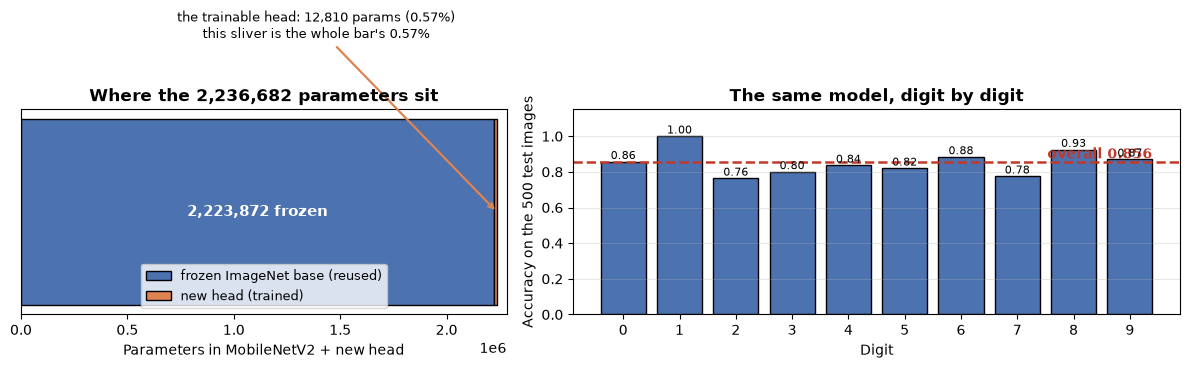

Frozen (reused): 2,223,872 parameters  = 99.43% of the model
Trainable (new head): 12,810 parameters  = 0.57% of the model
Overall test accuracy 0.856 | best digit 1 at 1.00 | worst digit 2 at 0.76


In [6]:

# WHAT: two panels - (1) where this model's 2.2M parameters actually sit, (2) how the frozen-transfer
#       model scores on each digit separately.
# WHY: "we reuse most of the model" is a claim about PARAMETERS, not about layer objects; and one
#      overall accuracy hides the fact that transfer works far better on some digits than others.
import matplotlib.pyplot as plt
import numpy as np

frozen_params = total - trainable          # both counted in Step 2, in real parameters

# Per-class accuracy on the same 500-image test subset scored above.
base.eval()
correct_by_class = np.zeros(10); count_by_class = np.zeros(10)
with torch.no_grad():
    for xb, yb in test_dl:
        pred = base(xb).argmax(1)
        for t, p in zip(yb.tolist(), pred.tolist()):
            count_by_class[t] += 1
            correct_by_class[t] += (t == p)
per_class = correct_by_class / np.maximum(count_by_class, 1)
overall = correct_by_class.sum() / count_by_class.sum()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2),
                               gridspec_kw={"width_ratios": [1, 1.25]})

# ── Left: one bar, split into the part we reuse and the part we train ─────────
axL.barh([0], [frozen_params], color="#4C72B0", edgecolor="black", height=0.45,
         label="frozen ImageNet base (reused)")
axL.barh([0], [trainable], left=[frozen_params], color="#DD8452", edgecolor="black", height=0.45,
         label="new head (trained)")
axL.annotate("the trainable head: %s params (%.2f%%)\nthis sliver is the whole bar's %.2f%%"
             % (format(trainable, ","), 100 * trainable / total, 100 * trainable / total),
             xy=(total, 0), xytext=(total * 0.62, 0.42), fontsize=9, ha="center",
             arrowprops=dict(arrowstyle="->", color="#DD8452", lw=1.6))
axL.text(frozen_params / 2, 0, format(frozen_params, ",") + " frozen",
         ha="center", va="center", color="white", fontsize=11, fontweight="bold")
axL.set_yticks([]); axL.set_xlim(0, total * 1.02)
axL.set_xlabel("Parameters in MobileNetV2 + new head")
axL.set_title("Where the %s parameters sit" % format(total, ","), fontsize=12, fontweight="bold")
axL.legend(loc="lower center", fontsize=9)

# ── Right: the same model's accuracy, digit by digit ─────────────────────────
bars = axR.bar(range(10), per_class, color="#4C72B0", edgecolor="black")
axR.axhline(overall, ls="--", color="#c0392b", lw=1.8)
axR.text(9.4, overall + 0.02, "overall %.3f" % overall, color="#c0392b",
         ha="right", fontsize=10, fontweight="bold")
for d, b in enumerate(bars):
    axR.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015,
             "%.2f" % per_class[d], ha="center", fontsize=8)
axR.set_xticks(range(10)); axR.set_xlabel("Digit")
axR.set_ylabel("Accuracy on the %d test images" % int(count_by_class.sum()))
axR.set_ylim(0, 1.15); axR.grid(axis="y", alpha=0.3)
axR.set_title("The same model, digit by digit", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

print("Frozen (reused): %s parameters  = %.2f%% of the model" % (format(frozen_params, ","), 100*frozen_params/total))
print("Trainable (new head): %s parameters  = %.2f%% of the model" % (format(trainable, ","), 100*trainable/total))
print("Overall test accuracy %.3f | best digit %d at %.2f | worst digit %d at %.2f"
      % (overall, int(np.argmax(per_class)), per_class.max(), int(np.argmin(per_class)), per_class.min()))


**Read the figure.** Left: a single bar holding every parameter in the model. The blue part is the frozen ImageNet base you downloaded and never touch; the orange sliver at the far right is the head you actually train — the arrow points at it because at this scale you can barely see it, and *that* is the claim "we reuse almost all of the model", stated in parameters rather than in layer objects. Right: the same frozen-transfer model's accuracy broken down by digit, with the red dashed line marking the single overall number. The bars are **not** level with that line — some digits are far above it and at least one is well below. An overall accuracy is an average over these ten bars, and averages are exactly where a weak class hides. The best and worst digits for this run are printed underneath.

## Going further: the same recipe on a harder dataset

Below, the identical freeze-and-replace-head pattern is applied with ResNet-18 on real CIFAR-10 photos — this is exactly how production teams adapt pre-trained models to custom categories.

## 🌍 Real-World Worked Example — Fine-Tune ResNet on Custom Categories

**Industry context:**
- **The default was tested and found wanting.** Raghu, Zhang, Kleinberg & Bengio ("Transfusion", NeurIPS 2019, [arXiv:1902.07208](https://arxiv.org/abs/1902.07208)) evaluated ImageNet transfer on two large-scale medical-imaging tasks and reported that "transfer offers little benefit to performance, and simple, lightweight models can perform comparably to ImageNet architectures".
- **The backbone-plus-head pattern is still universal.** Faster R-CNN (Ren, He, Girshick & Sun, NeurIPS 2015) put a pre-trained convolutional trunk under a task head; YOLO, SSD and DETR still ship that shape.
- **What to check before you copy it:** how close your images are to natural photographs, and how many labelled examples you actually have. Those two numbers decide the outcome, not the architecture.

We fine-tune a **pretrained ResNet-18** (ImageNet weights) on a small binary classification task.

In [7]:
# WHAT: a full transfer-learning demo - frozen ResNet-18 backbone, new 2-class head, trained on 400 photos.
# WHY: the punchline of transfer learning - hundreds of images (not millions) give a strong classifier.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# ── Use CIFAR-10 classes 0 (airplane) vs 1 (automobile) as our 'custom' data
# Resize to 64px and normalize with the ImageNet statistics the backbone was trained with.
transform = T.Compose([
    T.Resize(64), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # ImageNet stats
])
full = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True, download=True, transform=transform)
# Keep only classes 0 and 1
idx = [i for i,(x,y) in enumerate(full) if y in (0,1)][:400]
subset = Subset(full, idx)
train_size = int(0.8*len(subset))
train_ds, val_ds = torch.utils.data.random_split(subset, [train_size, len(subset)-train_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

# ── Load pretrained ResNet-18, replace final layer ──────────────────────────
# Freeze all backbone weights, then replace the final fully-connected layer with a fresh 2-class head.
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for p in model.parameters(): p.requires_grad = False        # Freeze backbone
model.fc = nn.Linear(model.fc.in_features, 2)               # Only train head

opt     = optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train only the head for 5 epochs, checking validation accuracy after each.
for epoch in range(5):
    model.train(); total_loss=0
    for X,y in train_dl:
        y_bin = (y % 2)  # remap to 0/1
        loss = loss_fn(model(X), y_bin)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for X,y in val_dl:
            y_bin = (y%2)
            correct += (model(X).argmax(1)==y_bin).sum().item(); total+=len(y_bin)
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_dl):.3f} | val acc: {correct/total*100:.1f}%")

print("\n✅ With only 400 images and 5 epochs, transfer learning gives strong results.")
print("A model trained from scratch would need 100x more data for similar performance.")

Epoch 1/5 — loss: 0.724 | val acc: 72.5%


Epoch 2/5 — loss: 0.479 | val acc: 80.0%


Epoch 3/5 — loss: 0.355 | val acc: 86.2%


Epoch 4/5 — loss: 0.293 | val acc: 85.0%


Epoch 5/5 — loss: 0.272 | val acc: 90.0%

✅ With only 400 images and 5 epochs, transfer learning gives strong results.
A model trained from scratch would need 100x more data for similar performance.


## ⚠️ Where this breaks

**This notebook contains its own counter-example. Read the number.**

- **Frozen ImageNet features plus 2 epochs of head training gave us 0.836 on MNIST** (2,000 training images, 500 test). The plain flat MLP trained from scratch in `unit1/01` reached **0.9135** on the same digits from 5,000 images, and the small from-scratch CNN in `unit2/01` reached **0.9867** from the full training set. The budgets differ, so treat this as a direction rather than a controlled result — and if you want the controlled version, retrain all three on the same 2,000 images and report what you get. Transfer learning *lost* here — because ImageNet is colour photographs of objects and MNIST is white strokes on black. **Domain distance is the variable that decides whether freezing helps**, and nothing about the technique warns you when it is large.
- **Raghu et al. found the same direction at research scale.** *Transfusion: Understanding Transfer Learning for Medical Imaging* (Raghu, Zhang, Kleinberg & Bengio, NeurIPS 2019, [arXiv:1902.07208](https://arxiv.org/abs/1902.07208)) evaluated ImageNet transfer on two large medical-imaging tasks and reported that "transfer offers little benefit to performance, and simple, lightweight models can perform comparably to ImageNet architectures". Note the exact wording: *little benefit*, not a loss — our MNIST result here is more extreme than theirs, and the reason is that our domain gap is more extreme.
- **Freezing cannot fix a resolution or channel mismatch.** MobileNetV2 demands 96×96 RGB, so we upsampled 28×28 grayscale and repeated the single channel three times. Every one of those pixels is invented. The backbone is now reading detail that does not exist.
- **What transfer learning cannot fix at all:** missing labels, wrong labels, class imbalance, or a target that is not visible in the input. A backbone supplies *features*. It never supplies supervision, and no amount of pre-training compensates for a label column that is 8% wrong.
- **The assumption that must hold:** your images and ImageNet's share low-level statistics — natural lighting, textures, object-centred framing. Check this by looking at your images next to ImageNet samples before you commit.
- **Cheaper alternative when the domains are far apart:** train a small CNN from scratch. On MNIST that is minutes on a CPU and it beats what we just measured.


## 🧩 Mini-exercise

**Try it:** Unfreeze the last few layers of the base (e.g. set `requires_grad=True` on the parameters of `base.features[-3:]` and pass them to the optimizer), then train for 1 more epoch with a small learning rate (e.g. 1e-5). Does accuracy improve?

---

## ✅ Summary

**What you did:** Loaded a pre-trained base (MobileNetV2), froze it, added a new head, and trained only the head on MNIST (resized to 96×96 RGB).

**In real life you'd also:** Use your own dataset, optionally fine-tune the last few layers, and tune learning rate.

**The main idea:** Transfer learning reuses pre-trained features so we need less data and time; freeze the base and train the new head first.

**Next:** `06_pretrained_cnn_architectures` explores ResNet/VGG/Inception; `07_training_cnn_image_datasets` covers full training pipelines.

## 📚 References

1. Yosinski, J., Clune, J., Bengio, Y. & Lipson, H. (2014). *How transferable are features in deep neural networks?* NeurIPS. https://arxiv.org/abs/1411.1792
2. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
3. Zhuang, F. et al. (2021). *A Comprehensive Survey on Transfer Learning*. Proceedings of the IEEE 109(1). https://arxiv.org/abs/1911.02685

**Recent work (2024–2026)**

4. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — "freeze the backbone, train a small head" is exactly how this model is meant to be used. The recipe you are learning survived; the backbone under it changed.
5. Bai et al. (2025). *Qwen2.5-VL Technical Report*. arXiv. https://arxiv.org/abs/2502.13923 — the vision-language alternative, when the downstream task is described in words rather than in labels.
